In [1]:
import os
os.chdir('../../../../..')

In [49]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], add_morgan_fingerprint=True)
molecules = qm9.get_molecules()
df = qm9.load()

2026-04-15 07:49:11.586 | INFO     | src.datasets:load:485 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-15 07:49:11.952 | INFO     | src.datasets:_sample_qm9_df:677 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-15 07:49:11.953 | INFO     | src.datasets:_add_requested_descriptors:125 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-15 07:49:11.954 | INFO     | src.features:compute_morgan_fingerprints:75 - Computing Morgan Fingerprints (Radius=3, Size=2048)...
2026-04-15 07:49:24.071 | INFO     | src.datasets:_add_requested_descriptors:148 - Added descriptor column(s): ['morgan_fingerprint']
2026-04-15 07:49:53.658 | SUCCESS  | src.datasets:get_molecules:1158 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).
2026-04-15 07:49:53.662 | INFO     | src.datasets:load:485 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-0

In [4]:
len(molecules[0:2])

2

In [5]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [6]:
def vectorized_tanimoto_distance(fingerprint_list):
    """
    Computes the full Tanimoto distance matrix using matrix algebra.
    fingerprint_list: list of Morgan fingerprint vectors.
    """
    X = np.array([np.array(m).flatten() for m in fingerprint_list], dtype=np.float32)
    intersection = X @ X.T
    row_sums = np.sum(X, axis=1)
    denominator = row_sums[:, None] + row_sums[None, :] - intersection

    with np.errstate(divide='ignore', invalid='ignore'):
        tanimoto_coeff = np.true_divide(intersection, denominator)
        tanimoto_coeff[~np.isfinite(tanimoto_coeff)] = 0

    return 1 - tanimoto_coeff

all_fingerprints = df['morgan_fingerprint'].to_list()
dist_matrix = vectorized_tanimoto_distance(all_fingerprints)

# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:09<00:00,  1.02it/s]


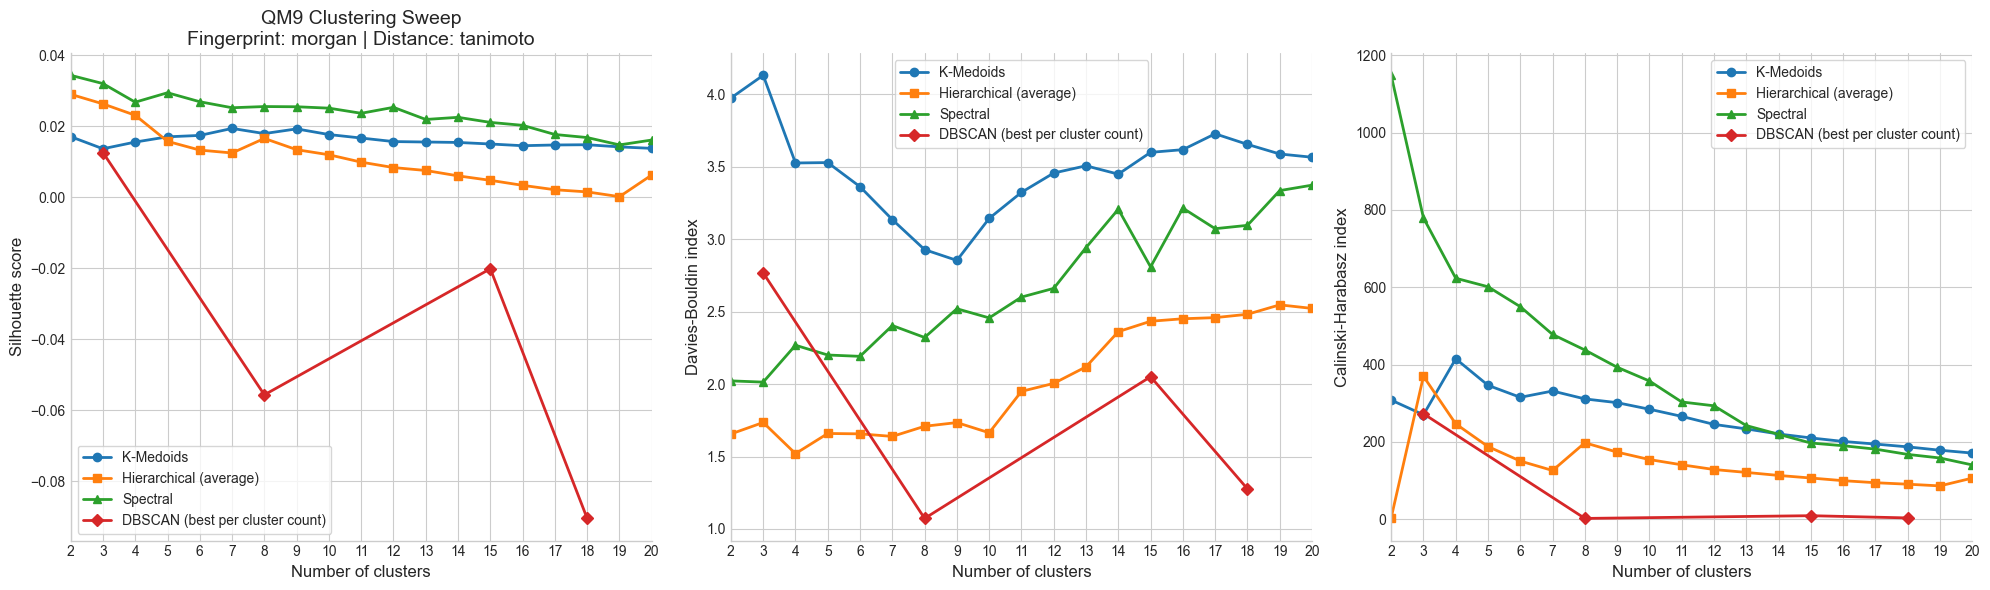

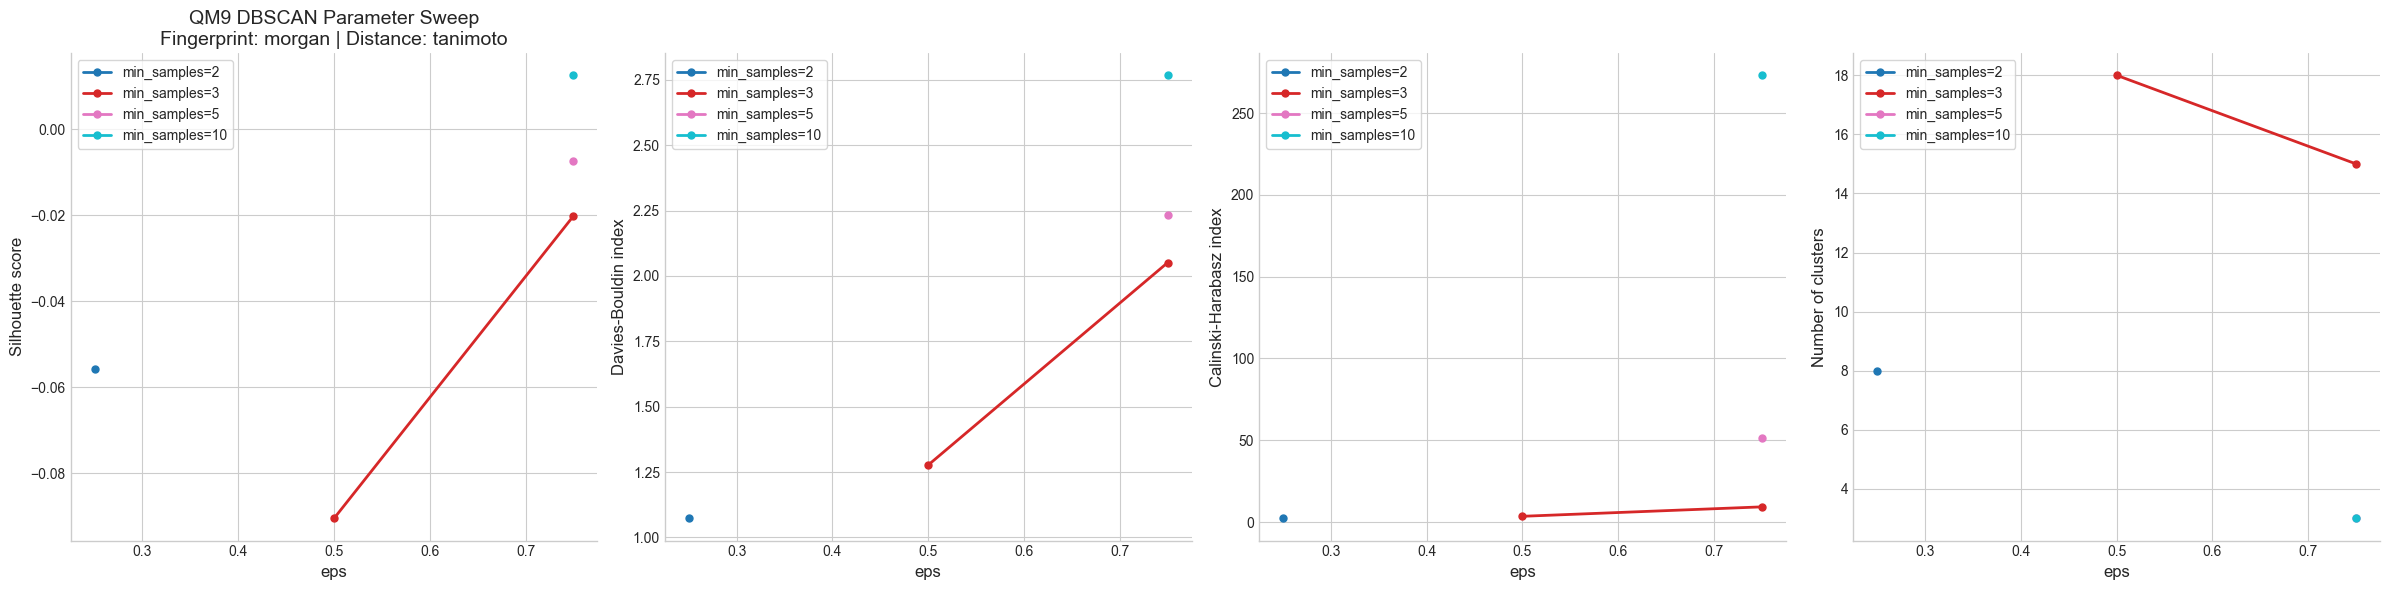

2026-04-15 07:52:05.413 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:840 - Saved clustering sweep plot to figures/qm9/clustering/tanimoto/morgan/clustering_sweep_2_to_20_clusters.png
2026-04-15 07:52:05.414 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:842 - Saved DBSCAN evaluation plot to figures/qm9/clustering/tanimoto/morgan/dbscan_parameter_sweep.png
2026-04-15 07:52:05.414 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:843 - Saved clustering sweep results to figures/qm9/clustering/tanimoto/morgan/clustering_sweep_2_to_20_clusters.json


In [7]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    dataset_name="qm9",
)

In [8]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(4966), np.int64(4967)), (np.int64(593), np.int64(4376)), (np.int64(413), np.int64(4473)), (np.int64(143), np.int64(3070)), (np.int64(236), np.int64(960)), (np.int64(128), np.int64(593)), (np.int64(448), np.int64(2336)), (np.int64(617), np.int64(1931)), (np.int64(23), np.int64(146)), (np.int64(128), np.int64(4376))]


In [10]:
plot_molecules_with_py3dmol(mols[1])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

In [33]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=3, linkage='average')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)

In [34]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [35]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-15 08:12:45.398 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_hierarchical_projection.png


{'coords': array([[ 1.2154468 ,  1.712778  ],
        [ 1.988336  , -1.6929991 ],
        [-0.26060414, -0.32860425],
        ...,
        [ 2.5795407 , -1.8415505 ],
        [-0.43429962, -0.38767165],
        [ 2.697333  , -1.5750895 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/morgan/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/morgan'),
 'clustering_method': 'hierarchical'}

In [36]:
average_numeric_by_cluster(df, "labels_hier")

Hierarchical Clustering
shape: (3, 58)
┌─────────────┬───────┬───────────┬────────────┬──────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬───────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬──────────┬───────────┬─────────────────┬───────────┐
│ labels_hier ┆ count ┆ num_atoms ┆ mol_weight ┆ logp     ┆ tpsa      ┆ election_affinity ┆ ionization_energies ┆ num_heavy_at

# KMedoids

In [37]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)

In [38]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [39]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-15 08:13:42.064 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_kmedoids_projection.png


{'coords': array([[ 1.2154468 ,  1.712778  ],
        [ 1.988336  , -1.6929991 ],
        [-0.26060414, -0.32860425],
        ...,
        [ 2.5795407 , -1.8415505 ],
        [-0.43429962, -0.38767165],
        [ 2.697333  , -1.5750895 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/morgan/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/morgan'),
 'clustering_method': 'kmedoids'}

In [40]:
average_numeric_by_cluster(df, "labels_km")

Hierarchical Clustering
shape: (3, 58)
┌───────────┬───────┬───────────┬────────────┬───────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬───────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬──────────┬─────────────┬─────────────────┬───────────┐
│ labels_km ┆ count ┆ num_atoms ┆ mol_weight ┆ logp      ┆ tpsa      ┆ election_affinity ┆ ionization_energies ┆ num_heavy_

# Spectral

In [44]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

In [20]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [43]:
labels_km

array([0, 1, 1, ..., 1, 0, 1], shape=(5000,), dtype=uint64)

In [22]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-15 07:54:16.142 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_spectral_projection.png


{'coords': array([[ 1.2154468 ,  1.712778  ],
        [ 1.988336  , -1.6929991 ],
        [-0.26060414, -0.32860425],
        ...,
        [ 2.5795407 , -1.8415505 ],
        [-0.43429962, -0.38767165],
        [ 2.697333  , -1.5750895 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/morgan/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/morgan'),
 'clustering_method': 'spectral'}

In [24]:
average_numeric_by_cluster(df, "labels_spectral")

Hierarchical Clustering
shape: (6, 57)
┌─────────────────┬───────┬───────────┬────────────┬──────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬───────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬──────────┬─────────────┬───────────┐
│ labels_spectral ┆ count ┆ num_atoms ┆ mol_weight ┆ logp     ┆ tpsa      ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ 

# DBSCAN 

In [26]:
model_db = DBSCAN(
    eps=0.5,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)

In [27]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [28]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-15 07:55:38.856 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_dbscan_projection.png


{'coords': array([[ 1.2154468 ,  1.712778  ],
        [ 1.988336  , -1.6929991 ],
        [-0.26060414, -0.32860425],
        ...,
        [ 2.5795407 , -1.8415505 ],
        [-0.43429962, -0.38767165],
        [ 2.697333  , -1.5750895 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/morgan/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/morgan'),
 'clustering_method': 'dbscan'}

In [29]:
average_numeric_by_cluster(df, "labels_db")

Hierarchical Clustering
shape: (201, 58)
┌───────────┬───────┬───────────┬────────────┬───────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬───────────┬───────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬─────────────┬─────────────┬─────────────┬────────────┬───────────┬──────────┬──────────┬─────────────┬───────────┬─────────────────┐
│ labels_db ┆ count ┆ num_atoms ┆ mol_weight ┆ logp      ┆ tpsa      ┆ election_affinity ┆ ionization_energies ┆ num

# KMeans on embedding

In [47]:
df

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,labels_hier,labels_km,labels_spectral,labels_db
str,str,str,str,str,str,i64,str,i64,i64,i64,f64,f64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],i64,u64,i32,i64
"""qm9_89""","""C3H5NO""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H][N][C][Branch1][C][H][Branc…","""ketone""",10,"""Aliphatic Ring""",71,0,29,0.761845,12.992522,5,1,0,2.0,0,0.0,0.333333,0.666667,1,2,4,0,1,2,4,20,1.261328,0,0,0,0,0,0,0,1,0,0,2,2.5257,39.34,-6.631414,-0.702054,5.929361,359.152008,2.167387,-6726.387695,-6726.26123,-6726.235352,-6727.135742,16.083,-40.819069,-41.077904,-41.309227,-38.114258,11.54185,4.90368,3.63309,"[0, 0, … 0]",2,0,0,-1
"""qm9_132""","""C4H10O""","""[H]C([H])([H])C([H])([H])OC([H…","""[H]C([H])([H])C([H])([H])OC([H…","""[H][C][Branch1][C][H][Branch1]…","""ether""",15,"""Acyclic""",74,1,9,0.936769,12.976237,5,0,0,1.866667,4,0.0,0.0,1.0,0,1,4,0,0,4,6,31,1.209514,0,0,0,0,0,0,0,0,1,0,1,0.9301,50.619999,-6.756587,2.53338,9.289967,631.081787,3.704885,-6355.161621,-6354.975098,-6354.949219,-6355.981445,22.881001,-56.966496,-57.358181,-57.718079,-52.897472,17.9608,2.23958,2.09578,"[0, 0, … 0]",2,1,0,-1
"""qm9_139""","""C3H4N2""","""[H]N1C([H])([H])[C@]1([H])C#N""","""[H]N1C([H])([H])[C@]1([H])C#N""","""[H][N][C][Branch1][C][H][Branc…","""""",9,"""Aliphatic Ring""",68,0,45,0.444793,13.026985,5,1,0,2.0,0,0.333333,0.0,0.666667,1,2,3,1,0,2,4,17,1.264596,0,0,0,0,0,0,0,0,0,0,2,2.8377,40.209999,-7.55116,0.206807,7.757967,386.555695,1.880987,-6152.69043,-6152.564453,-6152.538574,-6153.435547,15.572,-38.04356,-38.264439,-38.47002,-35.623112,17.103571,3.50921,3.35299,"[0, 0, … 0]",2,1,0,-1
"""qm9_144""","""C3H5NO""","""[H]C(=O)N1C([H])([H])C1([H])[H…","""[H]C(=O)N1C([H])([H])C1([H])[H…","""[H][C][=Branch1][C][=O][N][C][…","""amide""",10,"""Aliphatic Ring""",71,0,20,0.761845,12.992522,5,1,0,2.0,0,0.0,0.333333,0.666667,0,1,4,0,1,2,4,20,1.261934,0,0,0,0,1,0,0,0,0,0,2,3.2517,40.77,-6.952509,-0.035375,6.917135,383.601288,2.16589,-6726.451172,-6726.317871,-6726.291992,-6727.207031,16.197001,-40.882473,-41.134586,-41.36591,-38.185608,14.7497,3.94953,3.42803,"[0, 0, … 1]",2,2,0,-1
"""qm9_149""","""C4H8O""","""[H]OC([H])([H])C1([H])C([H])([…","""[H]OC([H])([H])C1([H])C([H])([…","""[H][O][C][Branch1][C][H][Branc…","""alcohol""",13,"""Aliphatic Ring""",72,0,20,0.964858,12.880514,5,1,0,2.0,2,0.0,0.0,1.0,1,1,4,0,0,4,5,27,1.240861,0,1,0,0,0,0,0,0,0,0,1,1.3201,46.009998,-7.077682,2.1497,9.224659,468.622894,3.110261,-6321.884277,-6321.729004,-6321.703125,-6322.664062,20.059,-50.915638,-51.26128,-51.569748,-47.386292,12.75002,3.20516,2.88061,"[0, 0, … 0]",2,1,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_130677""","""C4H5F3O2""","""[H]C(=O)O[C@]([H])(C([H])([H])…","""[H]C(=O)O[C@]([H])(C([H])([H])…","""[H][C][=Branch1][C][=O][O][C@]…","""ether,halogen""",14,"""Acyclic""",142,1,26,1.567518,13.752707,9,0,0,1.857143,2,0.0,0.25,0.75,0,2,4,0,1,3,5,28,1.279761,0,0,0,0,0,0,0,0,1,0,5,3.6403,52.540001,-7.93484,-0.185037,7.752524,1188.842651,2.583122,-16472.59375,-16472.349609,-16472.324219,-16473.541016,31.017,-59.400204,-59.694172,-60.02824,-55.291012,2.60612,1.14569,0.95669,"[0, 1, … 0

In [ ]:
embedding = np.array(df['morgan_fingerprint'].to_list())
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(embedding)
df = df.with_columns(kmeans_labels=kmeans_labels)

In [ ]:
create_chemiscope_viewer(df, embedding, kmeans_labels, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…